#Portas lógicas quânticas de 1 qubit

In [ ]:
%%capture
!pip install qiskit[visualization]==1.2.2
!pip install qiskit_aer
!pip install qiskit_ibm_runtime
!pip install matplotlib

In [2]:
import qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from math import sqrt
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram

##A representação mais geral para um qubit, é um vetor |ψ> definido no espaço de Hilbert

Nesse exemplo o qubit já foi criado como uma superposição uniforme dos dois estados básicos |0> e |1>.

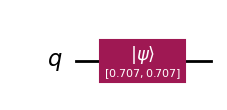

In [3]:
q = QuantumRegister(1, 'q')
circuito = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito.initialize(ψ, q[0])

circuito.draw('mpl')

In [4]:
ψ = qi.Statevector(circuito)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [5]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [6]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 490, '1': 534}


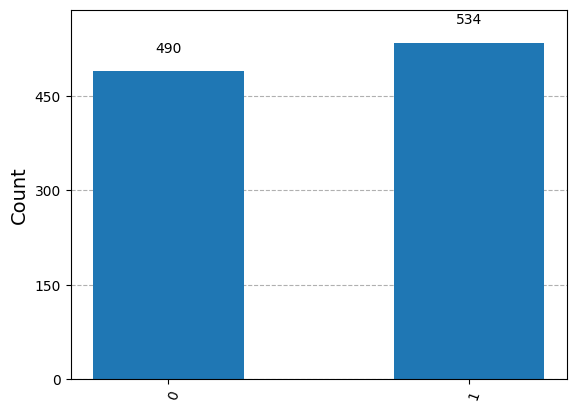

In [7]:
plot_histogram(counts)

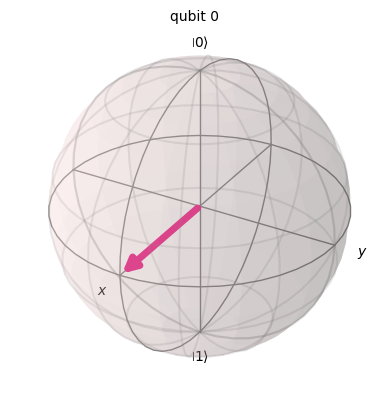

In [8]:
ψ.draw('bloch')

# Uma outra forma de inicializar o estado mais geral de 1 qubit

Esse é o caso mais simples e mais usual para inicializar o qubit. Perceba que o vetor tem o sentido apontado para o estado |0>, ou seja, isso indica que o qubit não está num estado de superposição.

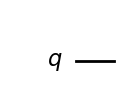

In [9]:
qc1 = QuantumCircuit(1)
qc1.draw('mpl')

In [10]:
ψ = qi.Statevector(qc1)
ψ

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [11]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [12]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


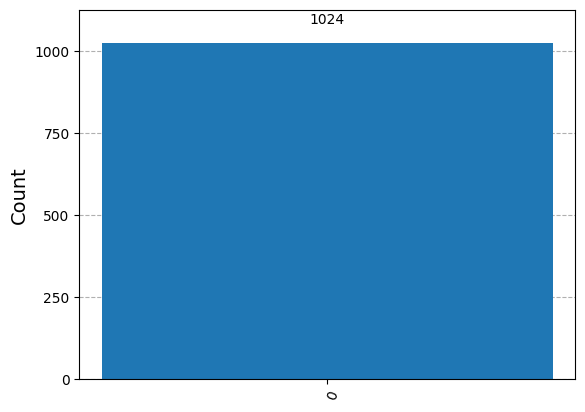

In [13]:
plot_histogram(counts)

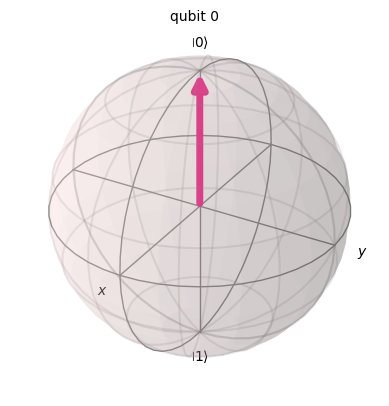

In [14]:
ψ.draw('bloch')

#Aplicando as portas de fase RX, RY e RZ

Agora que já sabemos inicializar os qubits, podemos aplicar as devidas portas RX, RY e RZ. Vamos aplicar cada uma individualmente e enteder o comportamento delas.

**Atuando com a Porta de Fase RX no circuito "qc2"**

A Porta 𝑹𝑿(𝜽) realiza uma rotação de 𝜃 radianos ao longo do eixo 𝑋. Ela é uma versão contínua da porta 𝑋, que corresponde a 𝑅𝑋(𝜋). Ao aplicar essa rotação, o qubit gira ao redor do eixo 𝑋, alterando seus coeficientes de superposição.

OBS: O circuito qc2 é o mesmo inicial qc1.

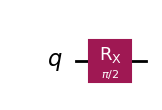

In [33]:
qc2 = QuantumCircuit(1)
qc2.rx(pi/2, 0)
qc2.draw('mpl')

In [34]:
ψ = qi.Statevector(qc2)
ψ

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


In [35]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [36]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 508, '1': 516}


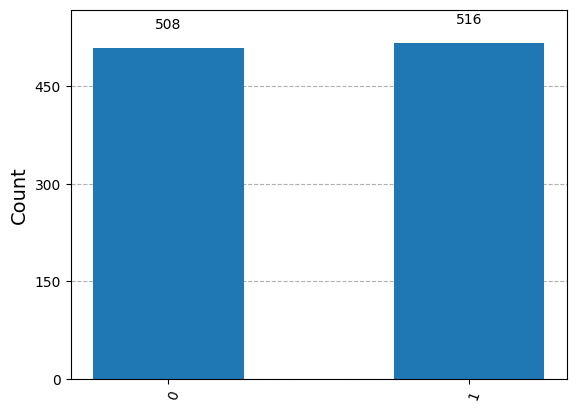

In [37]:
plot_histogram(counts)

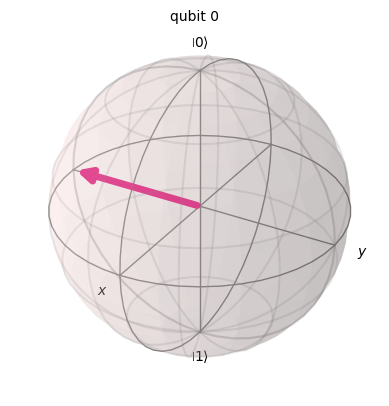

In [38]:
ψ.draw('bloch')

**Atuando com a Porta de Fase RX no Circuito "qc3"**

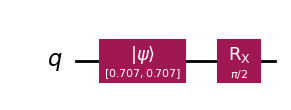

In [21]:
qc3 = circuito
qc3.rx(pi/2, 0)
qc3.draw('mpl')

In [22]:
ψ = qi.Statevector(qc3)
ψ

Statevector([0.5-0.5j, 0.5-0.5j],
            dims=(2,))


In [23]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [24]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 542, '1': 482}


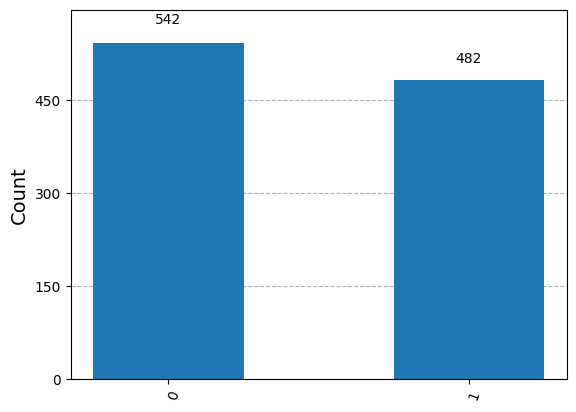

In [25]:
plot_histogram(counts)

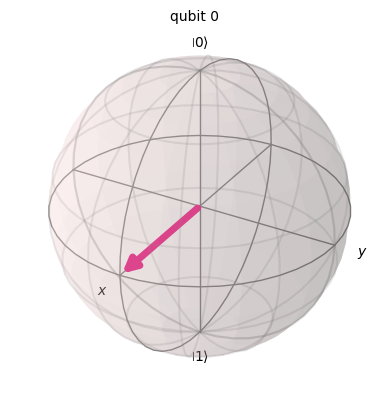

In [26]:
ψ.draw('bloch')

**Atuando com a Porta de Fase RY no circuito "qc4"**

Porta 𝑹𝒀(𝜽): realiza uma rotação de 𝜃 radianos ao longo do eixo 𝑌. É uma versão contínua da porta 𝑌, que equivale a 𝑅𝑌(𝜋). Isso altera tanto o estado do qubit quanto a fase de maneira controlada, de acordo com o valor de 𝜃.

OBS: O circuito qc4 é o mesmo inicial qc1.

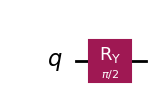

In [39]:
qc4 = QuantumCircuit(1)
qc4.ry(pi/2, 0)
qc4.draw('mpl')

In [40]:
ψ = qi.Statevector(qc4)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


In [41]:
probs = ψ.probabilities()
print(probs)

[0.5 0.5]


In [42]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 506, '1': 518}


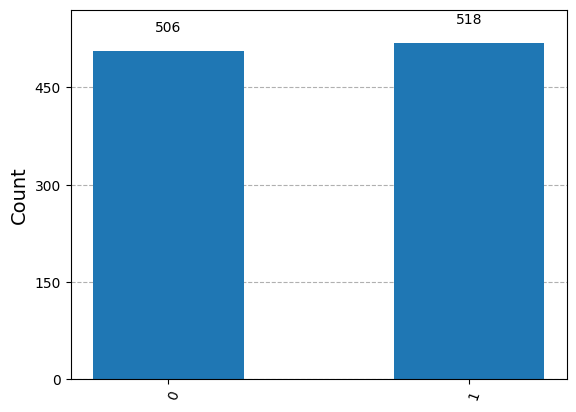

In [43]:
plot_histogram(counts)

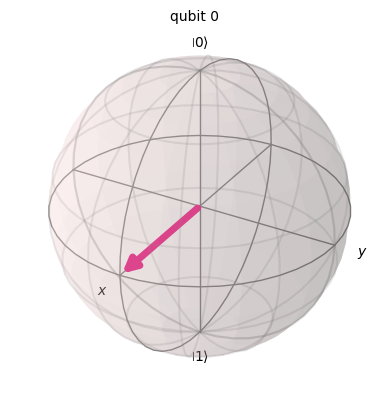

In [44]:
ψ.draw('bloch')

**Atuando com a Porta de Fase RY no Circuito "circuito2"**

Inicialmente criamos o cicuito2 para depois atuar com porta Y.

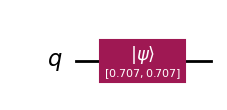

In [45]:
circuito2 = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito2.initialize(ψ, q[0])

circuito2.draw('mpl')

In [46]:
ψ = qi.Statevector(circuito2)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


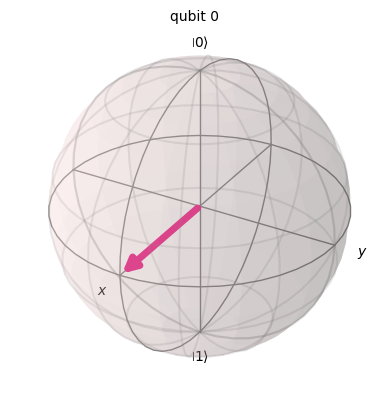

In [47]:
ψ.draw('bloch')

Agora atua com a Porta Pauli-Y

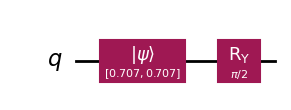

In [48]:
qc5 = circuito2
qc5.ry(pi/2, 0)
qc5.draw('mpl')

In [49]:
ψ = qi.Statevector(qc5)
ψ

Statevector([1.11022302e-16+0.j, 1.00000000e+00+0.j],
            dims=(2,))


In [50]:
probs = ψ.probabilities()
print(probs)

[1.23259516e-32 1.00000000e+00]


In [51]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'1': 1024}


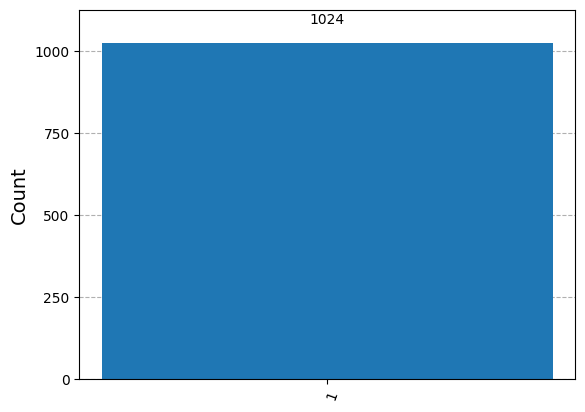

In [52]:
plot_histogram(counts)

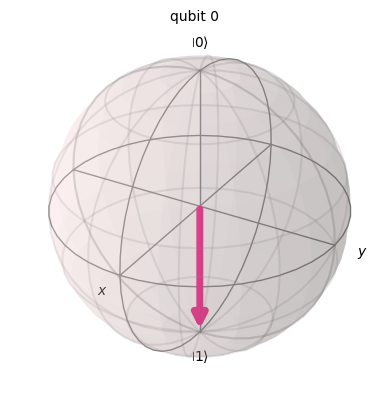

In [53]:
ψ.draw('bloch')

**Atuando com a Porta de Fase RZ no circuito "qc6"**

A Porta 𝑹𝒁(𝜽) aplica uma rotação de 𝜃 radianos ao longo do eixo 𝑍. Diferente das rotações 𝑅𝑋​ e 𝑅𝑌​, essa porta não altera a probabilidade de medir ∣0⟩ ou ∣1⟩, mas modifica a fase relativa entre esses estados, dependendo do ângulo 𝜃.

OBS: O circuito qc6 é o mesmo inicial qc1.

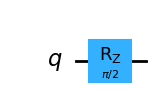

In [54]:
qc6 = QuantumCircuit(1)
qc6.rz(pi/2, 0)
qc6.draw('mpl')

In [55]:
ψ = qi.Statevector(qc6)
ψ

Statevector([0.70710678-0.70710678j, 0.        +0.j        ],
            dims=(2,))


In [56]:
probs = ψ.probabilities()
print(probs)

[1. 0.]


In [57]:
counts = ψ.sample_counts(shots=1024)
print(counts)

{'0': 1024}


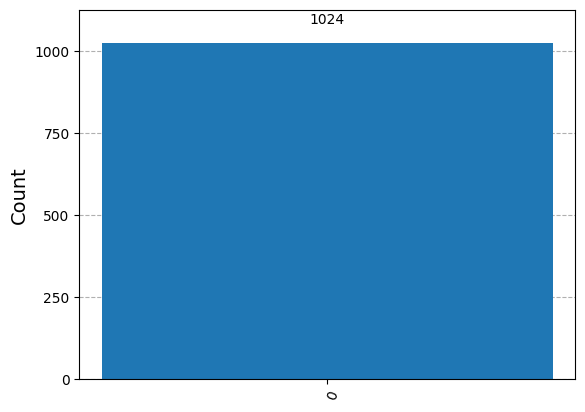

In [58]:
plot_histogram(counts)

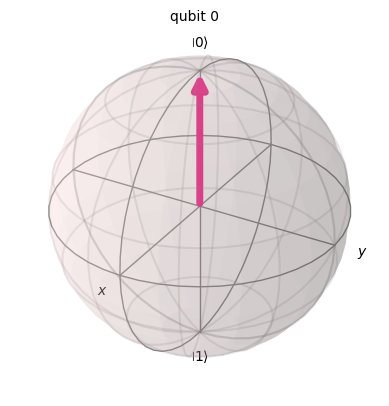

In [59]:
ψ.draw('bloch')

**Atuando com a Porta de Fase RZ no Circuito "circuito3"**

Inicialmente criamos o cicuito3 para depois atuar com porta RZ.

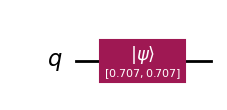

In [60]:
circuito3 = QuantumCircuit(1)

α = 1/sqrt(2)
β = 1/sqrt(2)

ψ = [α, β]
circuito3.initialize(ψ, q[0])

circuito3.draw('mpl')

In [61]:
ψ = qi.Statevector(circuito3)
ψ

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


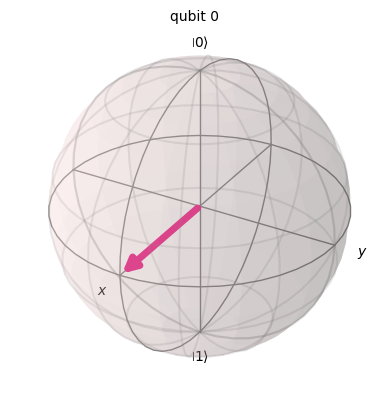

In [62]:
ψ.draw('bloch')

Agora atua com a Porta Pauli-Z

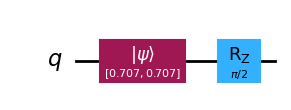

In [63]:
qc7 = circuito3
qc7.rz(pi/2, 0)
qc7.draw('mpl')

In [64]:
ψ = qi.Statevector(qc7)
ψ

Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


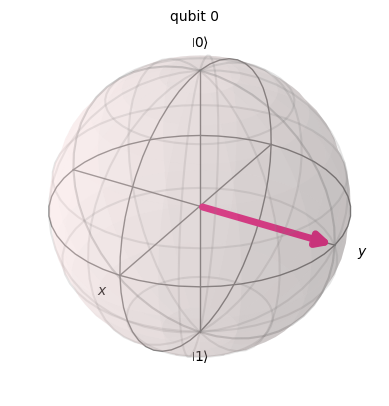

In [65]:
ψ.draw('bloch')